Loading FINAL_CLEAN_FULL_with_demo_apoe_age_fixed (1).csv...
Applying BIF...
Fixed 527 diagnostic reversals.


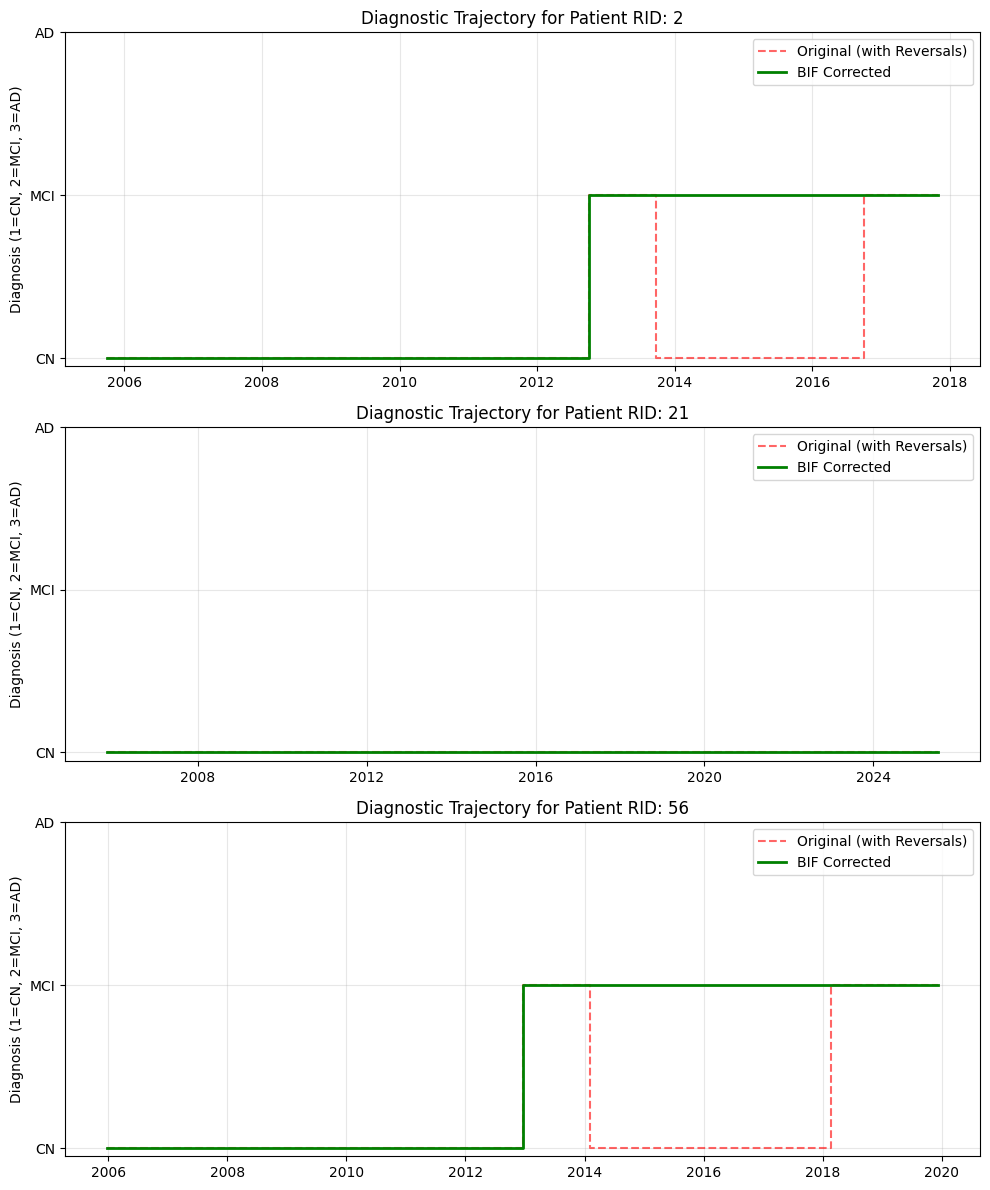

Successfully saved to RESEARCH_READY_BIF_CLEANED.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def finalize_and_visualize(input_csv, output_csv):

    print(f"Loading {input_csv}...")
    df = pd.read_csv(input_csv)


    df['EXAMDATE'] = pd.to_datetime(df['EXAMDATE'])
    df = df.sort_values(by=['RID', 'EXAMDATE'])


    print("Applying BIF...")
    df['DIAGNOSIS_BEFORE'] = df['DIAGNOSIS']
    df['DIAGNOSIS_AFTER'] = df.groupby('RID')['DIAGNOSIS'].cummax()


    reversals = df[df['DIAGNOSIS_BEFORE'] != df['DIAGNOSIS_AFTER']]
    print(f"Fixed {len(reversals)} diagnostic reversals.")


    sample_rids = reversals['RID'].unique()[:3]

    if len(sample_rids) > 0:
        fig, axes = plt.subplots(len(sample_rids), 1, figsize=(10, 4 * len(sample_rids)))
        if len(sample_rids) == 1: axes = [axes]

        for i, rid in enumerate(sample_rids):
            patient_data = df[df['RID'] == rid]

            axes[i].step(patient_data['EXAMDATE'], patient_data['DIAGNOSIS_BEFORE'],
                        where='post', label='Original (with Reversals)', linestyle='--', color='red', alpha=0.6)
            axes[i].step(patient_data['EXAMDATE'], patient_data['DIAGNOSIS_AFTER'],
                        where='post', label='BIF Corrected', linewidth=2, color='green')

            axes[i].set_title(f"Diagnostic Trajectory for Patient RID: {rid}")
            axes[i].set_ylabel("Diagnosis (1=CN, 2=MCI, 3=AD)")
            axes[i].set_yticks([1, 2, 3])
            axes[i].set_yticklabels(['CN', 'MCI', 'AD'])
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

  
    df['DIAGNOSIS'] = df['DIAGNOSIS_AFTER']
    df_final = df.drop(columns=['DIAGNOSIS_BEFORE', 'DIAGNOSIS_AFTER'])

    # Save
    df_final.to_csv(output_csv, index=False)
    print(f"Successfully saved to {output_csv}")

if __name__ == "__main__":
    INPUT_FILE = "FINAL_CLEAN_FULL_with_demo_apoe_age_fixed (1).csv"
    OUTPUT_FILE = "RESEARCH_READY_BIF_CLEANED.csv"
    finalize_and_visualize(INPUT_FILE, OUTPUT_FILE)

In [ ]:
import pandas as pd
import numpy as np

def generate_bif_report(file_path):

    df = pd.read_csv(file_path)

    mapping = {1.0: 'CN', 2.0: 'MCI', 3.0: 'AD'}

    print("--- BIF Cleaning Summary ---")


    dist = df['DIAGNOSIS'].map(mapping).value_counts()
    print("\nFinal Diagnosis Distribution (Including MCI):")
    print(dist)

  
    research_df = df[df['DIAGNOSIS'].isin([1.0, 3.0])].copy()

   
    research_df['TARGET'] = research_df['DIAGNOSIS'].map({1.0: 0, 3.0: 1})

    print("\n--- Research Dataset (CN vs AD) ---")
    print(f"Total Longitudinal Samples: {len(research_df)}")
    print(f"Unique Subjects: {research_df['RID'].nunique()}")
    print(f"CN Samples (0): {len(research_df[research_df['TARGET'] == 0])}")
    print(f"AD Samples (1): {len(research_df[research_df['TARGET'] == 1])}")

   
    output_name = "MODEL_READY_CN_AD_LONGITUDINAL.csv"
    research_df.to_csv(output_name, index=False)
    print(f"\nFinal Modeling Dataset saved as: {output_name}")

    return research_df

if __name__ == "__main__":
   
    generate_bif_report("RESEARCH_READY_BIF_CLEANED.csv")

--- BIF Cleaning Summary ---

Final Diagnosis Distribution (Including MCI):
DIAGNOSIS
MCI    6688
CN     5458
AD     2981
Name: count, dtype: int64

--- Research Dataset (CN vs AD) ---
Total Longitudinal Samples: 8439
Unique Subjects: 2573
CN Samples (0): 5458
AD Samples (1): 2981

Final Modeling Dataset saved as: MODEL_READY_CN_AD_LONGITUDINAL.csv


In [ ]:
!pip install --upgrade sympy==1.12 shap torch

INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 40.2 MB/s eta 

Training BiGRU (CN vs AD) on cpu...

PHASE 1 PERFORMANCE: CN vs AD
Accuracy:  0.9590
Recall:    0.9637 (Sensitivity)
F1-Score:  0.9466
ROC-AUC:   0.9879


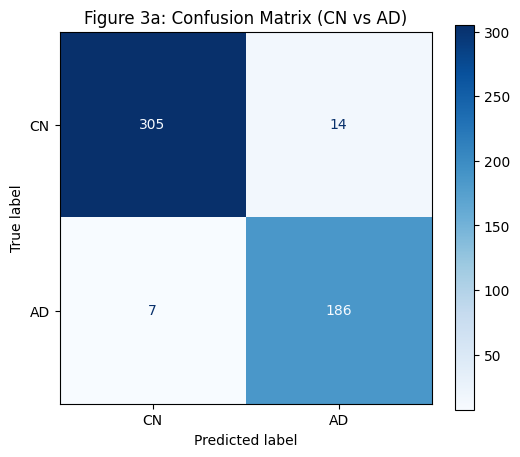

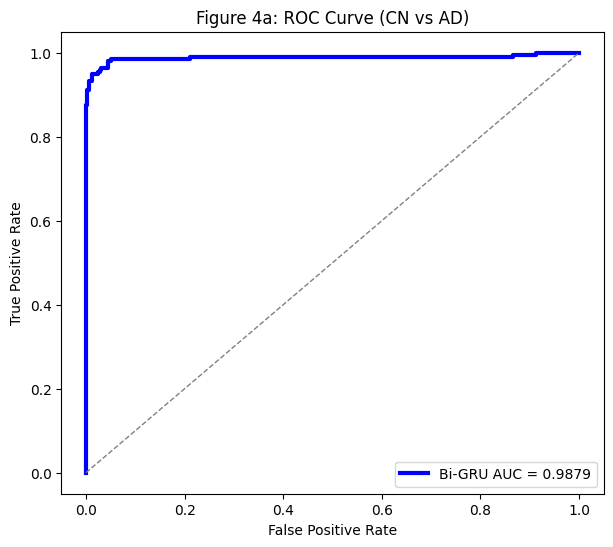


--- Generating SHAP Global Feature Importance (CN vs AD) ---


  0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_703/3460567288.py:97: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, background_2d, feature_names=feature_names, plot_type="bar", show=False)


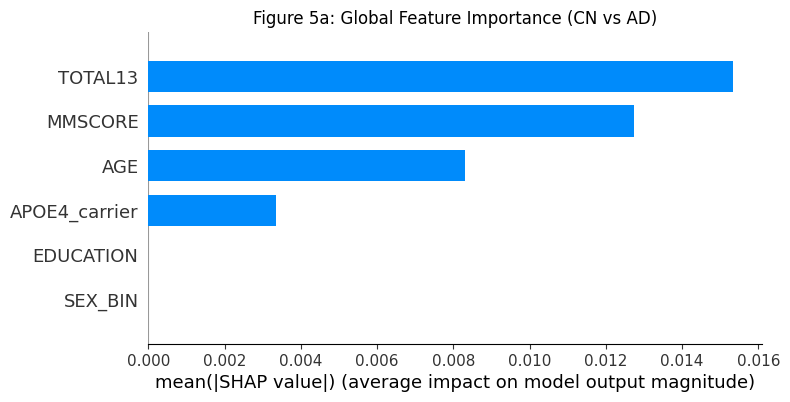

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report, roc_curve, auc,
                             confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
                             recall_score, f1_score, precision_score)
import matplotlib.pyplot as plt
import seaborn as sns
import shap


def prepare_sequences(file_path):
    df = pd.read_csv(file_path)
    features = ['MMSCORE', 'TOTAL13', 'AGE', 'SEX_BIN', 'EDUCATION', 'APOE4_carrier']
    target = 'DIAGNOSIS'


    df = df[df[target].isin([1.0, 3.0])].copy()
    if df.empty:
        raise ValueError("No data found for CN (1.0) or AD (3.0).")

    df = df.dropna(subset=features + [target])
    df['label'] = df[target].map({1.0: 0, 3.0: 1}).astype(int)

    scaler = StandardScaler()
    df[features] = scaler.fit_transform(df[features].fillna(df[features].mean()))

    subject_ids = df['PTID'].unique()
    np.random.seed(42)
    indices = np.random.permutation(len(subject_ids))
    train_size = int(len(subject_ids) * 0.8)
    train_ids = subject_ids[indices[:train_size]]

    train_data, test_data, train_labels, test_labels = [], [], [], []
    for ptid, group in df.groupby('PTID'):
        if 'EXAMDATE' in group.columns:
            group = group.sort_values('EXAMDATE')
        seq = group[features].values
        label = group['label'].iloc[-1]
        if ptid in train_ids:
            train_data.append(torch.FloatTensor(seq))
            train_labels.append(label)
        else:
            test_data.append(torch.FloatTensor(seq))
            test_labels.append(label)

    return train_data, train_labels, test_data, test_labels, len(features), features


class ADDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.sequences[idx], self.labels[idx]

def collate_fn(batch):
    sequences, labels = zip(*batch)
    padded_seqs = nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, torch.LongTensor(labels)


class BiGRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(BiGRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers,
                          batch_first=True, bidirectional=True, dropout=0.2)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.gru(x, h0)
        return self.fc(out[:, -1, :])

# 4. SHAP Analysis (Figure 5a)
def run_shap_analysis(model, loader, feature_names, device):
    print("\n--- Generating SHAP Global Feature Importance (CN vs AD) ---")
    model.eval()
    batch_x, _ = next(iter(loader))
    background_2d = batch_x[:50, -1, :].numpy()

    def model_predict_fixed(data_2d):
        data_3d = torch.FloatTensor(data_2d).unsqueeze(1).to(device)
        with torch.no_grad():
            outputs = model(data_3d)
            return torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()

    explainer = shap.KernelExplainer(model_predict_fixed, background_2d)
    shap_values = explainer.shap_values(background_2d)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, background_2d, feature_names=feature_names, plot_type="bar", show=False)
    plt.title("Figure 5a: Global Feature Importance (CN vs AD)")
    plt.savefig('Figure_5a_SHAP_CN_AD.png', dpi=300, bbox_inches='tight')
    plt.show()


def train_model():
    file_path = 'RESEARCH_READY_BIF_CLEANED.csv'
    train_seqs, train_labs, test_seqs, test_labs, input_dim, f_names = prepare_sequences(file_path)

    train_loader = DataLoader(ADDataset(train_seqs, train_labs), batch_size=32, shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(ADDataset(test_seqs, test_labs), batch_size=32, shuffle=False, collate_fn=collate_fn)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = BiGRUModel(input_dim, 64, 2, 2).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    print(f"Training BiGRU (CN vs AD) on {device}...")
    for epoch in range(50):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_x), batch_y)
            loss.backward(); optimizer.step()

    # Evaluation
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for bx, by in test_loader:
            out = model(bx.to(device))
            all_probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(by.numpy())

    acc = accuracy_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc_val = roc_auc_score(all_labels, all_probs)

    print("\n" + "="*40)
    print("PHASE 1 PERFORMANCE: CN vs AD")
    print("="*40)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {rec:.4f} (Sensitivity)")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc_val:.4f}")
    print("="*40)


    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['CN', 'AD'])
    disp.plot(cmap='Blues', ax=plt.gca())
    plt.title("Figure 3a: Confusion Matrix (CN vs AD)")
    plt.grid(False)
    plt.savefig('Figure_3a_CM_CN_AD.png', dpi=300, bbox_inches='tight')
    plt.show()


    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='blue', lw=3, label=f'Bi-GRU AUC = {auc_val:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Figure 4a: ROC Curve (CN vs AD)')
    plt.legend(loc="lower right")
    plt.savefig('Figure_4a_ROC_CN_AD.png', dpi=300, bbox_inches='tight')
    plt.show()


    run_shap_analysis(model, test_loader, f_names, device)

if __name__ == "__main__":
    train_model()

Loading FINAL_CLEAN_FULL_with_demo_apoe_age_fixed (1).csv...
Applying BIF...
Successfully identified and fixed 527 diagnostic reversals.


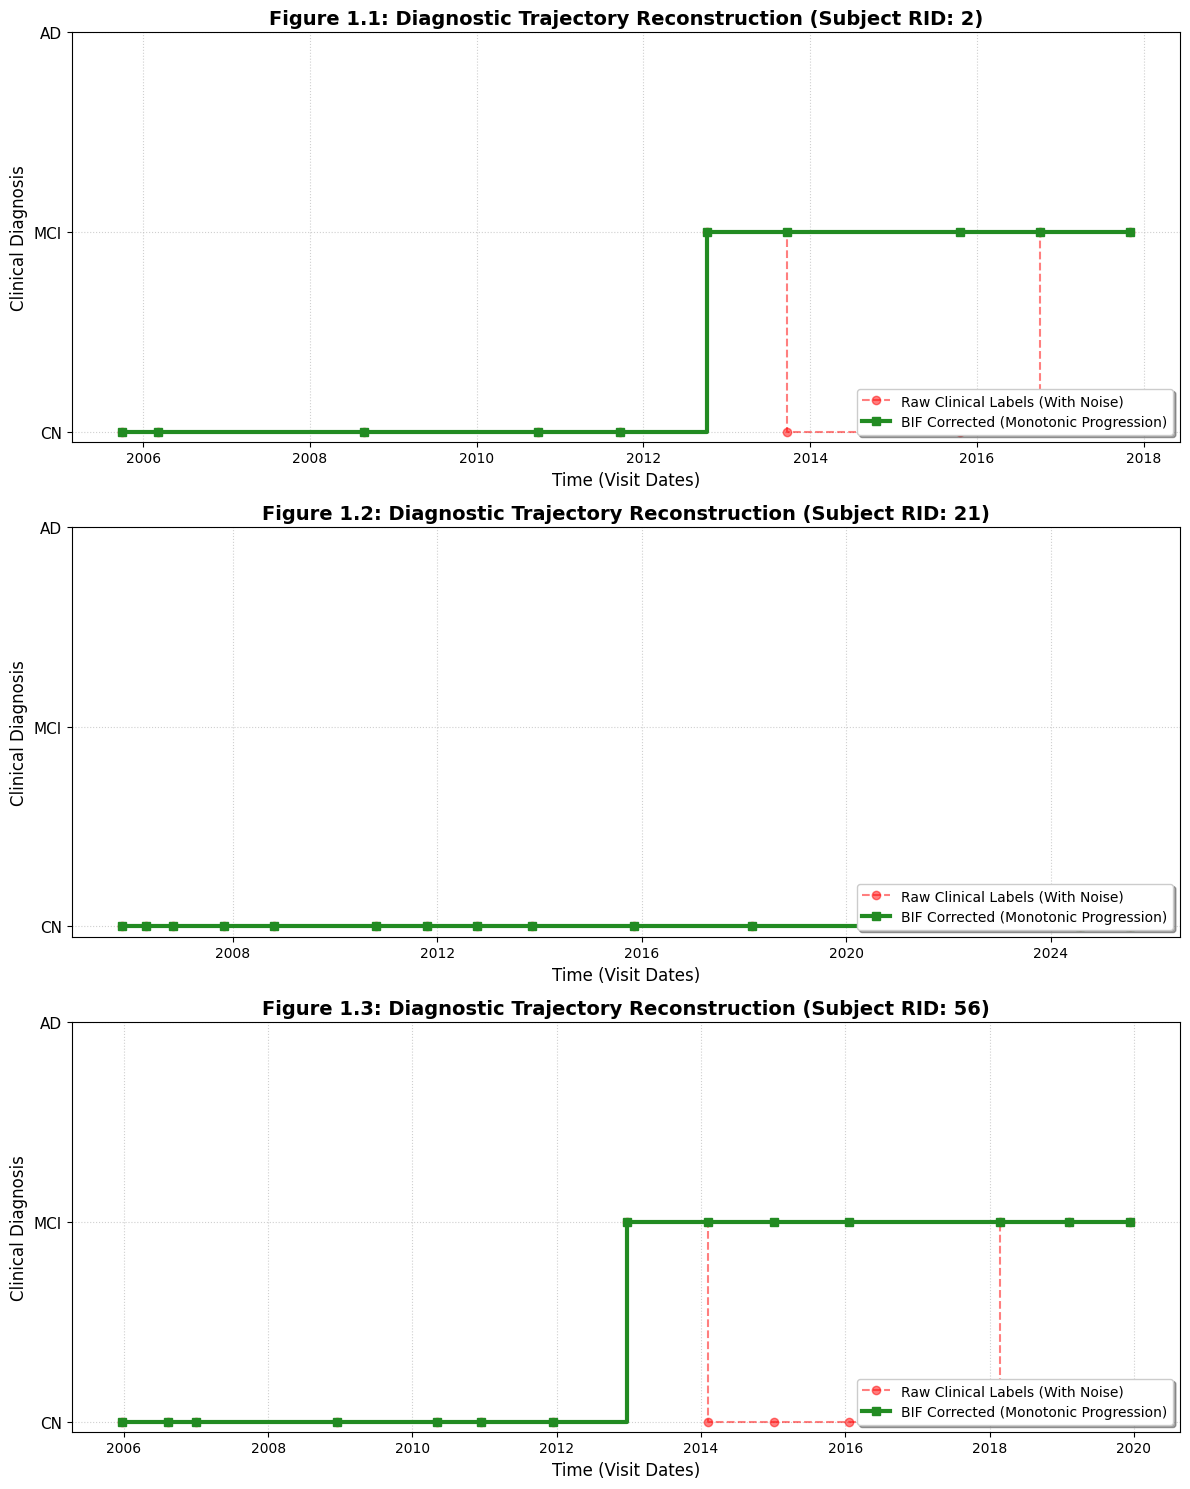

Successfully exported 'Figure_1_BIF_Protocol_Logic.png' at 300 DPI.
Successfully saved research-ready dataset to RESEARCH_READY_BIF_CLEANED.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def finalize_and_visualize(input_csv, output_csv):
    # 1. Load the dataset
    print(f"Loading {input_csv}...")
    df = pd.read_csv(input_csv)


    df['EXAMDATE'] = pd.to_datetime(df['EXAMDATE'])
    df = df.sort_values(by=['RID', 'EXAMDATE'])

    print("Applying BIF...")
    df['DIAGNOSIS_BEFORE'] = df['DIAGNOSIS']

    df['DIAGNOSIS_AFTER'] = df.groupby('RID')['DIAGNOSIS'].cummax()

    reversals = df[df['DIAGNOSIS_BEFORE'] != df['DIAGNOSIS_AFTER']]
    print(f"Successfully identified and fixed {len(reversals)} diagnostic reversals.")


    sample_rids = reversals['RID'].unique()[:3]

    if len(sample_rids) > 0:

        fig, axes = plt.subplots(len(sample_rids), 1, figsize=(12, 5 * len(sample_rids)))
        if len(sample_rids) == 1: axes = [axes]

        for i, rid in enumerate(sample_rids):
            patient_data = df[df['RID'] == rid]


            axes[i].step(patient_data['EXAMDATE'], patient_data['DIAGNOSIS_BEFORE'],
                        where='post', label='Raw Clinical Labels (With Noise)',
                        linestyle='--', color='red', alpha=0.5, marker='o')


            axes[i].step(patient_data['EXAMDATE'], patient_data['DIAGNOSIS_AFTER'],
                        where='post', label='BIF Corrected (Monotonic Progression)',
                        linewidth=3, color='forestgreen', marker='s')

            axes[i].set_title(f"Figure 1.{i+1}: Diagnostic Trajectory Reconstruction (Subject RID: {rid})",
                              fontsize=14, fontweight='bold')
            axes[i].set_ylabel("Clinical Diagnosis", fontsize=12)
            axes[i].set_xlabel("Time (Visit Dates)", fontsize=12)
            axes[i].set_yticks([1, 2, 3])
            axes[i].set_yticklabels(['CN', 'MCI', 'AD'], fontsize=11)
            axes[i].legend(frameon=True, shadow=True, loc='lower right')
            axes[i].grid(True, linestyle=':', alpha=0.6)

        plt.tight_layout()

        
        plt.savefig('Figure_1_BIF_Protocol_Logic.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Successfully exported 'Figure_1_BIF_Protocol_Logic.png' at 300 DPI.")

   
    df['DIAGNOSIS'] = df['DIAGNOSIS_AFTER']

    df_final = df.drop(columns=['DIAGNOSIS_BEFORE', 'DIAGNOSIS_AFTER'])

    
    df_final.to_csv(output_csv, index=False)
    print(f"Successfully saved research-ready dataset to {output_csv}")

if __name__ == "__main__":
   
    INPUT_FILE = "FINAL_CLEAN_FULL_with_demo_apoe_age_fixed (1).csv"
    OUTPUT_FILE = "RESEARCH_READY_BIF_CLEANED.csv"
    finalize_and_visualize(INPUT_FILE, OUTPUT_FILE)